# Imports (Run this first)

In [81]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.image as mpimg
from pathlib import Path
import os
import glob
from PIL import Image
from IPython.display import display
from IPython.display import Image as dis_image 
from descartes import PolygonPatch
import alphashape
from shapely.geometry import Point, Polygon
import random
import math
from IPython.display import clear_output
import spacy
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score)
import matplotlib.cm 
from matplotlib.colors import LinearSegmentedColormap 
import seaborn as sns
import csv
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Load Data

In [85]:
file_path = './data_here/sample reports/sub_sample_reports_L1_input.txt'
big_df = pd.read_csv(file_path, sep='\t')
results_df = pd.read_table('./data_here/all_results.txt', delimiter='\t')

/var/folders/ng/046x7_y97pjfh18029ryg4y80000gn/T/ipykernel_84888/3884071685.py:2: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  big_df = pd.read_csv(file_path, sep='\t')


# Trial Viewer Functions

In [86]:
def get_file_mappings():

    with open('mappings.json', 'r') as f:
        mappings_dict = json.load(f)

    return mappings_dict

def read_interest_area(trial_name):
    boundary = []
    subject = ['',[],[]]
    with open("./data_here/interest areas/"+trial_name, "r") as file:
        
        content = file.read()
        bounds = content.split('\n')
        for i in range(2):
            items = bounds[i].split()
            subject[0] = items[-1]
            
            x_coords = []
            y_coords = []
            for coord in items[2:-1]:
                x, y = map(int, coord.split(','))
                x_coords.append(x)
                y_coords.append(y)
                
            subject[1] = x_coords
            subject[2] = y_coords
            boundary.append(subject)
            subject = ['',[],[]]

    return boundary

def get_file_names():

    folder_path = Path("./data_here/interest areas")
    file_names = [file.name for file in folder_path.iterdir() if file.is_file()]

    return file_names

def is_point_in_shape(x1, y1, x2, y2, coord):
    bound1 = list(zip(x1, y1))
    bound2 = list(zip(x2, y2))

    alpha_shape1 = Polygon(bound1)
    alpha_shape2 = Polygon(bound2)

    point = Point(coord[0], coord[1])

    if alpha_shape1.contains(point):
        area = "bound1"
    elif alpha_shape2.contains(point):
        area = "bound2"
    else:
        area = "empty"

    return area

def get_image_pos(image_name):
    file_path = './data_here/pic_dimensions.txt'
    positions = {}
    with open(file_path, newline='') as csvfile:
        reader = csv.DictReader(csvfile, delimiter='\t')
        for row in reader:
            pos_str = row['position'].strip('()')
            x_str, y_str = pos_str.split(',')
            x, y = float(x_str), float(y_str)
            positions[row['picture']] = (x, y)

    pos = positions.get(image_name, None)
    if pos is None:
        raise FileNotFoundError(f"Image '{image_name}' not found in the positions file.")
    return pos

def get_image_name(bound_file_name):
    image_file_path = './data_here/target images'
    direction = bound_file_name[-5]
    
    if direction not in ('L', 'R'):
        raise ValueError(f"Invalid direction '{direction}' extracted from '{bound_file_name}'. Expected 'L' or 'R'.")

    stripped_name = bound_file_name[:-6]
    for filename in os.listdir(image_file_path):
        if stripped_name in filename and filename[-5] == direction:
            return filename

    raise FileNotFoundError(f"No matching image file found for '{bound_file_name}' with direction '{direction}'.")
    
def plot_trial(x_plots, y_plots, trial_name, num_frames=20, save_folder="plot_images"):
    folder_path = "./plot_images"
    image_name = get_image_name(trial_name)
    image_pos = get_image_pos(image_name)
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename != ".gitignore":  # Ensure it's a file, not a folder
            os.remove(file_path)
        
    os.makedirs(save_folder, exist_ok=True)
    
    # Filter out None values
    valid_indices = ~np.isnan(x_plots) & ~np.isnan(y_plots)
    x_plots = np.array(x_plots)[valid_indices]
    y_plots = np.array(y_plots)[valid_indices]

    boundary = read_interest_area(trial_name)
    x_bound1 = boundary[0][1]
    x_bound1.append(x_bound1[0])
    y_bound1 = boundary[0][2]
    y_bound1.append(y_bound1[0])
    x_bound2 = boundary[1][1]
    x_bound2.append(x_bound2[0])
    y_bound2 = boundary[1][2]
    y_bound2.append(y_bound2[0])

    # Generate evenly spaced indices
    indices = np.linspace(0, len(x_plots) - 1, num_frames, dtype=int)
    img = mpimg.imread('./data_here/target images/'+ image_name)
    height, width, _ = img.shape

    half_width = width / 2
    half_height = height / 2
    xmin = image_pos[0] - half_width
    xmax = image_pos[0] + half_width
    ymin = image_pos[1] - half_height
    ymax = image_pos[1] + half_height

    for i in indices:
        plt.figure(figsize=(6, 6), facecolor="white")
        
        plt.imshow(img, extent=[xmin, xmax, ymax, ymin], aspect='auto', alpha = 0.3)
        
        plt.plot(x_plots[:i+1], y_plots[:i+1], marker='o', linestyle='-', color='blue', zorder = 3)
        plt.plot(x_bound1, y_bound1, marker='o', linestyle='-', color='red')
        plt.plot(x_bound2, y_bound2, marker='o', linestyle='-', color='green')
        section = is_point_in_shape(x_bound1, y_bound1, x_bound2, y_bound2, [x_plots[i], y_plots[i]])
        if section == "bound1":
            plt.scatter(x_plots[i], y_plots[i], c='red', zorder=4)
        elif section == "bound2":
            plt.scatter(x_plots[i], y_plots[i], c='green', zorder=4)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.title('Trial')
        plot_filename = os.path.join(save_folder, f"{str(i)}.png")
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        plt.close()

def get_trial_coords(subitem):
    filtered_df = results_df[results_df['subitem'] == subitem]
    x_plots = filtered_df['X_coord'].replace('empty', None).astype(float).tolist()
    y_plots = filtered_df['Y_coord'].replace('empty', None).astype(float).tolist()
    return x_plots, y_plots

def get_trial_name(item):
    file_mappings = get_file_mappings() 
    item_str = str(item)

    if item_str not in file_mappings:
        raise ValueError(f"Item {item} not found in file mappings.")

    file_entry = file_mappings[item_str]
    if file_entry == "N/A" or not file_entry.strip():
        raise FileNotFoundError(f"No file associated with item {item} (got 'N/A').")

    file_names = file_entry.split()
    return file_names[0]


def show_trial_plot(subitem, frames=20):
    x_coord, y_coord = get_trial_coords(subitem)
    plot_trial(x_coord, y_coord, get_trial_name(subitem[7:]), frames)  
    display_plot_gif("animated_GMM", r"plot_images")
    display(dis_image(filename="saved_gifs/animated_GMM.gif"))

def display_plot_gif(title, img_folder):
    os.makedirs("saved_gifs", exist_ok=True)
    folder_path = "./saved_gifs"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename != ".gitignore":  # Ensure it's a file, not a folder
            os.remove(file_path)
            
    files = glob.glob(img_folder+r"/*.png")
    files = sorted(files, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))  # Sort numerically
    
    image_array = []
    progress = 0

    for my_file in files:
        progress += 1
    
        image = Image.open(my_file)
        image_array.append(image)

    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)
    plt.axis('off')

    def update(i):
        im.set_array(image_array[i])
        return im,

    # Create the animation object
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=200, blit=True,repeat_delay=10,)

    animation_fig.save("./saved_gifs/"+ title +".gif")
    plt.close()

# Generate Trial Viewer Animation

MovieWriter ffmpeg unavailable; using Pillow instead.


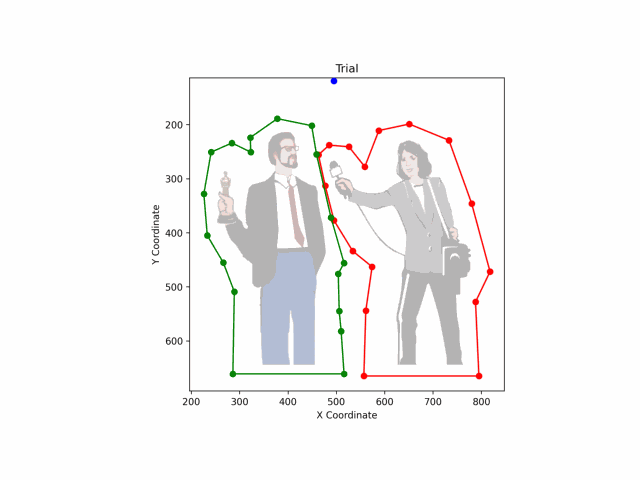

In [83]:
# (trial name, frames)
show_trial_plot('sub119_43', 20)

# Heatmap Functions

In [87]:
def add_colored_text(sentence, num_green_words):
    fig = plt.gcf()
    words = sentence.split()
    
    # Ensure we don't exceed the length of the sentence
    num_green_words = min(num_green_words, len(words))

    # Set the starting position (middle bottom of the figure)
    x_position = 0.12
    y_position = 0.01

    fig.canvas.draw()  # Required to render text properly
    renderer = fig.canvas.get_renderer()

    # Loop through each word and color accordingly
    current_x = x_position
    for i, word in enumerate(words):
        color = "green" if i < num_green_words else "black"

        text_obj = fig.text(current_x, y_position, word, color=color, fontsize=12, ha='left')
        
        bbox = text_obj.get_window_extent(renderer=renderer)
        text_width = bbox.width / fig.dpi  # Convert from pixels to figure coordinates

        current_x += (text_width/6) + 0.01

def get_sentence_timings(item, time, sentence_len):
    the1_offset = results_df[results_df["item"] == item]["the1_offset"].mean()
    agent_offset = results_df[results_df["item"] == item]["agent_offset"].mean()
    the2_offset = results_df[results_df["item"] == item]["the2_offset"].mean()
    patient_offset = results_df[results_df["item"] == item]["patient_offset"].mean()
    the2_onset = results_df[results_df["item"] == item]["the2_onset"].mean()

    if time >= patient_offset:
        return int(sentence_len)
    elif time >= the2_offset:
        return int(sentence_len - 1)
    elif time >= the2_onset:
        return int(sentence_len - 2)
    elif time >= agent_offset:
        return 2
    elif time >= the1_offset:
        return 1
    else:
        return 0

def gen_heatmap_frame(item, timestamp, sentence):
    image_name = get_image_name(get_trial_name(item))
    image_pos = get_image_pos(image_name)
    save_folder="heat_images"
    os.makedirs(save_folder, exist_ok=True)

    plt.clf()
    # add alpha (transparency) to a colormap
    wd = matplotlib.cm.winter._segmentdata # only has r,g,b  
    wd['alpha'] =  ((0.0, 0.0, 0.3), 
                   (0.3, 0.3, 1.0),
                   (1.0, 1.0, 1.0))
    
    # modified colormap with changing alpha
    al_winter = LinearSegmentedColormap('AlphaWinter', wd) 
    
    # get the map image as an array so it can be plotted 
    map_img = mpimg.imread('./data_here/target images/'+ image_name) 

    height, width, _ = map_img.shape

    half_width = width / 2
    half_height = height / 2
    xmin = image_pos[0] - half_width
    xmax = image_pos[0] + half_width
    ymin = image_pos[1] - half_height
    ymax = image_pos[1] + half_height

    item_df = results_df.loc[results_df['item'] == item].loc[results_df['participant_language'] == 'BILINGUAL'].loc[results_df['Time'] == timestamp]
    x_vals = item_df['X_coord'].tolist()
    y_vals = item_df['Y_coord'].tolist()
    
    # Ensure both arrays are processed together
    valid_indices = [i for i, (x, y) in enumerate(zip(x_vals, y_vals)) if x != 'empty' and y != 'empty']
    
    x_vals = np.array([float(x_vals[i]) for i in valid_indices])
    y_vals = np.array([float(y_vals[i]) for i in valid_indices])
    
    # Define grid resolution
    resolution = 30
    
    # Create 2D histogram
    heatmap, xedges, yedges = np.histogram2d(x_vals, y_vals, bins=resolution, range=[[0, 1000], [0, 1000]])

    # Calculate scaling factors to map image position to heatmap grid
    x_scale = (xedges[-1] - xedges[0]) / resolution
    y_scale = (yedges[-1] - yedges[0]) / resolution
    
    # Scale the image position to align with the heatmap grid
    xmin_scaled = xmin * (1 / x_scale)
    xmax_scaled = xmax * (1 / x_scale)
    ymin_scaled = ymin * (1 / y_scale)
    ymax_scaled = ymax * (1 / y_scale)

    fig, ax = plt.subplots()
    
    hmax = sns.heatmap(heatmap.T,
                cmap = matplotlib.cm.winter,
                alpha = 0.7, # whole heatmap is translucent
                annot = False,
                zorder = 2,
                xticklabels=False, 
                yticklabels=False,
                vmax=5
                )
    
    # heatmap uses pcolormesh instead of imshow, so we can't pass through 
    # extent as a kwarg, so we can't mmatch the heatmap to the map. Instead, 
    # match the map to the heatmap:
    
    hmax.imshow(map_img,
              aspect = hmax.get_aspect(),
              extent = [xmin_scaled, xmax_scaled, ymax_scaled, ymin_scaled],
              zorder = 1) #put the map under the heatmap

    add_colored_text(sentence, num_green_words=get_sentence_timings(item, timestamp, len(sentence.split())))


    plot_filename = os.path.join(save_folder, f"{str(timestamp)}.png")
    #plt.show()
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)


def gen_all_HM_frames(item, frame_intervale=10):
    sentence = get_all_sentences()[item]
    folder_path = "./heat_images"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename != ".gitignore":  # Ensure it's a file, not a folder
            os.remove(file_path)
        
    os.makedirs("heat_images", exist_ok=True)
    
    item_df = results_df.loc[results_df['item'] == item]
    for i in range(item_df['Time'].min(), item_df['Time'].max()+1, frame_intervale):
        gen_heatmap_frame(item, i, sentence)
        print(i, "/", item_df['Time'].max())
        clear_output(wait=True)

    display_plot_gif("animated_heatmap", r"heat_images")

def get_all_sentences():
    filtered_df = big_df[big_df['order_at_study'] != 0]
    unique_sentences_df = filtered_df.drop_duplicates(subset='sentence')
    return dict(zip(unique_sentences_df['order_at_study'], unique_sentences_df['sentence']))


# Generate Heatmap Animation

MovieWriter ffmpeg unavailable; using Pillow instead.


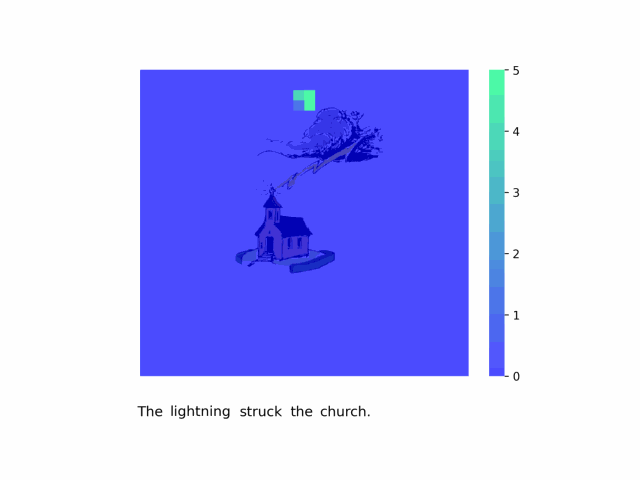

<Figure size 640x480 with 0 Axes>

In [88]:
# (item, frame interval (higher = less frames))
gen_all_HM_frames(20, 100)
display(dis_image(filename="saved_gifs/animated_heatmap.gif"))

# Generate complete dataset with derived features (modify for augmented and minority aug datasets)

In [191]:
def get_subitem_data(subitem):
    x_coords, y_coords = get_trial_coords(subitem)
    filtered_df = results_df[results_df['subitem'] == subitem]
    last_area = 'empty'
    area_order = 0
    gaze_shift = 0
    distractions = -1
    distracted = False
    a_dists = []
    b_dists = []
    a_centroid, b_centroid = get_activity_centroids(filtered_df['item'].unique()[0])
    agent_react_time = None
    patient_react_time = None
    agent_leave_time = None
    patient_leave_time = None
    agent_anti_altered = False
    patient_anti_altered = False
    anticipated_agent_onset = False
    anticipated_patient_onset = False

    agent_onset = filtered_df['agent_onset'].unique()[0]
    agent_offset = filtered_df['agent_offset'].unique()[0]
    patient_onset = filtered_df['patient_onset'].unique()[0]
    patient_offset = filtered_df['patient_offset'].unique()[0]
    
    for index, row in filtered_df.iterrows():
        current_area = row['IntAr']
        if last_area == 'agent' and current_area == 'patient':
            area_order = int(1)
            break
        elif last_area == 'patient' and current_area == 'agent':
            area_order = int(2)
            break
        elif current_area != 'empty':
            last_area = current_area

    last_area = 'empty'
    for index, row in filtered_df.iterrows():
        current_area = row['IntAr']
        if row['X_coord'] == 'empty':
            continue
        elif last_area != current_area:
            gaze_shift += 1 # gaze shift includes all area changes except nan values
            last_area = current_area
            distracted = False
        elif last_area == 'empty' and current_area == 'empty' and not distracted:
            distractions += 1
            distracted = True
        if current_area == 'agent' and row['Time'] >= agent_onset and agent_react_time == None:
            agent_react_time = float(row['Time'] - agent_onset)
        if current_area == 'patient' and row['Time'] >= patient_onset and patient_react_time == None:
            patient_react_time = float(row['Time'] - patient_onset)
        if current_area != 'agent' and agent_react_time != None and agent_leave_time == None:
            agent_leave_time = float(row['Time'] - agent_onset)
        if current_area != 'patient' and patient_react_time != None and patient_leave_time == None:
            patient_leave_time = float(row['Time'] - patient_onset)
        if row['Time'] >= agent_onset and not agent_anti_altered:
            if current_area == 'agent':
                anticipated_agent_onset = True
            elif current_area != 'agent':
                anticipated_agent_onset = False
            agent_anti_altered = True
        if row['Time'] >= patient_onset and not patient_anti_altered:
            if current_area == 'patient':
                anticipated_patient_onset = True
            elif current_area != 'agent':
                anticipated_patient_onset = False
            patient_anti_altered = True
            

    #print(agent_react_time)
    #print(agent_leave_time)

    agent_df = filtered_df[(filtered_df['Time'] >= agent_onset) & (filtered_df['Time'] <= agent_offset)]
    patient_df = filtered_df[(filtered_df['Time'] >= patient_onset) & (filtered_df['Time'] <= patient_offset)]

    TA_strict_a = ((agent_df['IntAr'] == 'agent').sum()) / len(agent_df)
    TA_strict_b = ((patient_df['IntAr'] == 'patient').sum()) / len(patient_df)

    TA_loose_a = False if (agent_df['IntAr'] == 'agent').sum() == 0 else True
    TA_loose_b = False if (patient_df['IntAr'] == 'patient').sum() == 0 else True

    order = 1 if agent_onset < patient_onset else 2
    ordered = True if area_order == order else False

    for i in range(len(x_coords)):
        a_dists.append(math.dist((x_coords[i], y_coords[i]), a_centroid))
        b_dists.append(math.dist((x_coords[i], y_coords[i]), b_centroid)) 

    duration_agent = (filtered_df['IntAr'] == 'agent').sum() * 10
    duration_patient = (filtered_df['IntAr'] == 'patient').sum() * 10
    duration_empty = (filtered_df['IntAr'] == 'empty').sum() * 10

    similarity = get_semantic_relationship(subitem)

    test_accuracy = False if filtered_df['memory_accuracy'].unique()[0] == "incorrect_response" else True
        
    return x_coords, y_coords, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, similarity, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, patient_leave_time, anticipated_agent_onset, anticipated_patient_onset

def get_activity_centroids(item):
    item_df = results_df[results_df['item'] == item]
    
    a_item_df = item_df[item_df['IntAr'] == 'agent']
    x_mean = pd.to_numeric(a_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(a_item_df['Y_coord'], errors='coerce').mean()
    a_centroid = (x_mean, y_mean)
    
    b_item_df = item_df[item_df['IntAr'] == 'patient']
    x_mean = pd.to_numeric(b_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(b_item_df['Y_coord'], errors='coerce').mean()
    b_centroid = (x_mean, y_mean)

    return a_centroid, b_centroid


def jitter(array, noise_level=2):
    noise = np.random.normal(0, noise_level, size=array.shape)
    return array + noise


def get_semantic_relationship(trial):
    nlp = spacy.load('en_core_web_md')
    df = results_df[results_df['subitem'] == trial]
    agent = nlp(df['agent'].unique()[0])
    patient = nlp(df['patient'].unique()[0])

    similarity = agent.similarity(patient)
    return similarity


def gen_training_dataframe():
    complete_df = pd.DataFrame(columns=['subitem', 'item', 'participent_language', 'x_coords', 'y_coords', 'area_order', 'gaze_shift', 'distractions', 'TA_strict_a', 
                                        'TA_strict_b', 'TA_loose_a', 'TA_loose_b', 'ordered', 'a_dists', 'b_dists', 'duration_agent', 
                                        'duration_patient', 'duration_empty', 'semantic_relationship', 'test_accuracy', 'agent_react_time', 
                                        'patient_react_time', 'agent_leave_time', 'patient_leave_time', 'agent_focus_on_onset', 
                                        'patient_focus_on_onset'])
    #trial = "sub101_16" #12, 16, 17
    for trial in results_df['subitem'].unique():
        item = results_df.loc[results_df['subitem'] == trial, 'item'].unique()[0]
        participent_language = results_df.loc[results_df['subitem'] == trial, 'participant_language'].unique()[0]
        x, y, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, semantic_relationship, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, patient_leave_time, anticipated_agent_onset, anticipated_patient_onset = get_subitem_data(trial)
        complete_df.loc[len(complete_df)] = [trial, item, participent_language, x, y, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, 
                                             TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, 
                                             semantic_relationship, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, 
                                             patient_leave_time, anticipated_agent_onset, anticipated_patient_onset]
        #print(complete_df.loc[len(complete_df)-1])
        print(trial)
        clear_output(wait=True)

        #Uncomment to generate an augmented dataset
        
        #Doubling data by adding random noise random noise
        #print(results_df.loc[results_df['subitem'] == trial, 'memory_accuracy'].unique()[0])
        #if results_df.loc[results_df['subitem'] == trial, 'memory_accuracy'].unique()[0] == 'incorrect_response':
        #a_dists = []
        #b_dists = []
        #a_centroid, b_centroid = get_activity_centroids(results_df[results_df['subitem'] == trial]['item'].unique()[0])
        #for i in range(len(x)):
        #    a_dists.append(math.dist((x[i], y[i]), a_centroid))
        #    b_dists.append(math.dist((x[i], y[i]), b_centroid)) 
        #complete_df.loc[len(complete_df)] = [trial+'B', item, participent_language, jitter(np.array(x)), jitter(np.array(y)), area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, 
        #                                     TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, 
        #                                     semantic_relationship, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, 
        #                                     patient_leave_time, anticipated_agent_onset, anticipated_patient_onset]
        #print(trial+'B')
        #clear_output(wait=True)

    return complete_df

complete_df = gen_training_dataframe()
complete_df.to_json("complete_df.json", orient="records", lines=True)
complete_df


,subitem,item,participent_language,x_coords,y_coords,area_order,gaze_shift,distractions,TA_strict_a,TA_strict_b,...,duration_patient,duration_empty,semantic_relationship,test_accuracy,agent_react_time,patient_react_time,agent_leave_time,patient_leave_time,agent_focus_on_onset,patient_focus_on_onset
0,sub101_1,1,L1_participant,"[484.3, 484.3, 484.3, nan, nan, 516.4, 516.4, ...","[131.0, 131.0, 131.0, nan, nan, 75.6, 75.6, 75...",1,3,0,1.000000,0.000000,...,380,340,0.030116,False,3.0,556.0,1743.0,976.0,True,False
1,sub101_2,2,L1_participant,"[524.3, 524.3, 524.3, 524.3, 524.3, 524.3, 524...","[77.8, 77.8, 77.8, 77.8, 77.8, 77.8, 77.8, 77....",2,4,0,0.000000,0.000000,...,2630,300,0.168012,True,860.0,707.0,1760.0,2157.0,False,False
2,sub101_3,3,L1_participant,"[533.9, 533.9, 533.9, 533.9, 533.9, 533.9, 533...","[105.2, 105.2, 105.2, 105.2, 105.2, 105.2, 105...",1,6,1,0.488372,0.862069,...,1050,770,0.099115,True,5.0,87.0,255.0,667.0,True,False
3,sub101_4,4,L1_participant,"[520.3, 520.3, 520.3, 520.3, 520.3, 520.3, 520...","[97.7, 97.7, 97.7, 97.7, 97.7, 97.7, 97.7, 97....",2,8,0,1.000000,0.236364,...,990,880,0.055178,False,8.0,66.0,928.0,236.0,True,True
4,sub101_5,5,L1_participant,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",2,7,1,0.561644,0.388889,...,1620,1250,0.285078,False,324.0,7.0,804.0,327.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,sub201_18,18,BILINGUAL,"[508.5, 508.5, 508.5, 508.5, 508.5, 508.5, 508...","[99.7, 99.7, 99.7, 99.7, 99.7, 99.7, 99.7, 99....",1,5,0,0.554217,1.000000,...,2370,830,-0.038727,False,212.0,8.0,732.0,1448.0,False,True
4336,sub201_19,19,BILINGUAL,"[514.9, 514.9, 514.9, 514.9, 514.9, 514.9, 514...","[103.6, 103.6, 103.6, 103.6, 103.6, 103.6, 103...",0,1,0,0.000000,1.000000,...,3630,370,-0.008012,True,NaN,5.0,NaN,NaN,False,True
4337,sub201_20,20,BILINGUAL,"[508.0, 508.0, 508.0, 508.0, 508.0, 508.0, 508...","[101.5, 101.5, 101.5, 101.5, 101.5, 101.5, 101...",1,5,0,0.084746,0.375000,...,540,970,0.110938,True,1.0,9.0,111.0,399.0,True,True
4338,sub201_21,21,BILINGUAL,"[512.7, 512.7, 512.7, 512.7, 512.7, 512.7, 512...","[106.7, 106.7, 106.7, 106.7, 106.7, 106.7, 106...",1,3,0,0.000000,1.000000,...,2900,360,0.087532,False,2881.0,7.0,NaN,1497.0,False,True


# Load Sub sample reports

In [89]:
file_path = './data_here/sample reports/sub_sample_reports_L1_input.txt'
df = pd.read_csv(file_path, sep='\t')
file_path = './data_here/sample reports/sub_sample_reports_L2_input.txt'
df2 = pd.read_csv(file_path, sep='\t')

/var/folders/ng/046x7_y97pjfh18029ryg4y80000gn/T/ipykernel_84888/707798928.py:2: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='\t')
/var/folders/ng/046x7_y97pjfh18029ryg4y80000gn/T/ipykernel_84888/707798928.py:4: DtypeWarning: Columns (12,13,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(file_path, sep='\t')


# Distance Centroid Graphs

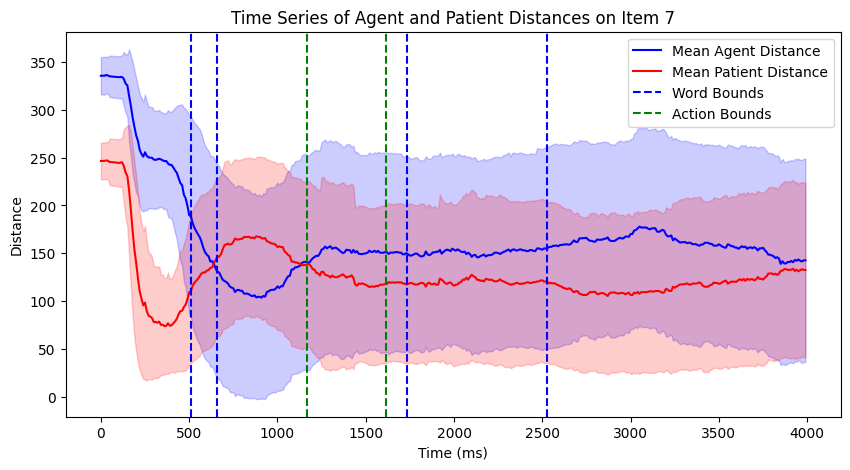

In [158]:
test_item = 7

# Filter DataFrame for the test item
edited_df = complete_df[complete_df['item'] == test_item]

# Extract mean onsets and offsets
the1_onset = results_df[results_df["item"] == test_item]["the1_onset"].mean()
agent_onset = results_df[results_df["item"] == test_item]["agent_onset"].mean()
agent_offset = results_df[results_df["item"] == test_item]["agent_offset"].mean()
the2_onset = results_df[results_df["item"] == test_item]["the2_onset"].mean()
patient_onset = results_df[results_df["item"] == test_item]["patient_onset"].mean()
patient_offset = results_df[results_df["item"] == test_item]["patient_offset"].mean()

# Convert 'a_dists' and 'b_dists' columns to NumPy arrays
a_dists_array = np.array(edited_df['a_dists'].tolist(), dtype=np.float64)
b_dists_array = np.array(edited_df['b_dists'].tolist(), dtype=np.float64)

# Compute mean and variance while ignoring NaNs
a_mean = np.nanmean(a_dists_array, axis=0)
a_var = np.nanvar(a_dists_array, axis=0)

b_mean = np.nanmean(b_dists_array, axis=0)
b_var = np.nanvar(b_dists_array, axis=0)

# Create time points (assuming 10ms intervals)
time_points = np.arange(0, len(a_mean) * 10, 10)  # in milliseconds

# Plot
plt.figure(figsize=(10, 5))

# Plot 'a_dists' in blue
line1, = plt.plot(time_points, a_mean, label="Mean Agent Distance", color='b')
plt.fill_between(time_points, 
                 a_mean - np.sqrt(a_var),  
                 a_mean + np.sqrt(a_var),  
                 color='b', alpha=0.2)

# Plot 'b_dists' in red
line2, = plt.plot(time_points, b_mean, label="Mean Patient Distance", color='r')
plt.fill_between(time_points, 
                 b_mean - np.sqrt(b_var),  
                 b_mean + np.sqrt(b_var),  
                 color='r', alpha=0.2)

# Add vertical lines for onsets and offsets
line3 = plt.axvline(x=the1_onset, color='b', linestyle='--', label="The1 Onset")
line4 = plt.axvline(x=agent_onset, color='b', linestyle='--', label="Agent Onset")
line5 = plt.axvline(x=agent_offset, color='g', linestyle='--', label="Agent Offset")
line6 = plt.axvline(x=the2_onset, color='g', linestyle='--', label="The2 Onset")
line7 = plt.axvline(x=patient_onset, color='b', linestyle='--', label="Patient Onset")
line8 = plt.axvline(x=patient_offset, color='b', linestyle='--', label="Patient Offset")

# Remove grid lines
plt.grid(False)

# Include only certain items
plt.legend([line1, line2, line4, line6], 
           ["Mean Agent Distance", "Mean Patient Distance", "Word Bounds", "Action Bounds"])

# Labels and Title
plt.xlabel("Time (ms)")
plt.ylabel("Distance")
plt.title(f"Time Series of Agent and Patient Distances on Item {test_item}")

# Show the plot
plt.show()

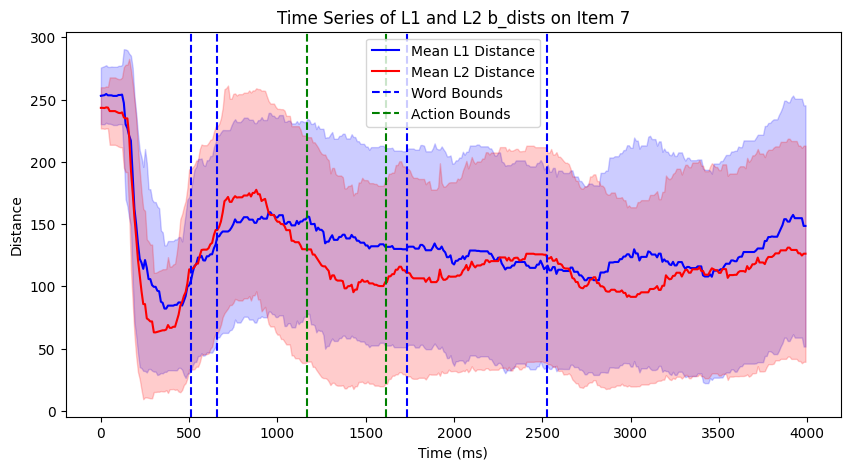

In [192]:
test_item = 7
dist_focus = 'b_dists' # Make this two shades of blue and a red version for patient

# Filter DataFrame for the test item
edited_df = complete_df[complete_df['item'] == test_item]
edited_df_L1 = edited_df[edited_df['participent_language'] == 'L1_participant']
edited_df_L2 = edited_df[edited_df['participent_language'] == 'L2_participant']
edited_df_BI = edited_df[edited_df['participent_language'] == 'BILINGUAL']

# Extract mean onsets and offsets
the1_onset = results_df[results_df["item"] == test_item]["the1_onset"].mean()
agent_onset = results_df[results_df["item"] == test_item]["agent_onset"].mean()
agent_offset = results_df[results_df["item"] == test_item]["agent_offset"].mean()
the2_onset = results_df[results_df["item"] == test_item]["the2_onset"].mean()
patient_onset = results_df[results_df["item"] == test_item]["patient_onset"].mean()
patient_offset = results_df[results_df["item"] == test_item]["patient_offset"].mean()

L1_array = np.array(edited_df_L1[dist_focus].tolist(), dtype=np.float64)
L2_array = np.array(edited_df_L2[dist_focus].tolist(), dtype=np.float64)
BI_array = np.array(edited_df_BI[dist_focus].tolist(), dtype=np.float64)

# Compute mean and variance while ignoring NaNs
L1_mean = np.nanmean(L1_array, axis=0)
L1_var = np.nanvar(L1_array, axis=0)

L2_mean = np.nanmean(L2_array, axis=0)
L2_var = np.nanvar(L2_array, axis=0)

BI_mean = np.nanmean(BI_array, axis=0)
BI_var = np.nanvar(BI_array, axis=0)

# Create time points (assuming 10ms intervals)
time_points = np.arange(0, len(L1_mean) * 10, 10)  # in milliseconds

# Plot
plt.figure(figsize=(10, 5))

line1, = plt.plot(time_points, L1_mean, label="Mean L1 Agent Distance", color='b')
plt.fill_between(time_points, 
                 L1_mean - np.sqrt(L1_var),  
                 L1_mean + np.sqrt(L1_var),  
                 color='b', alpha=0.2)

line2, = plt.plot(time_points, L2_mean, label="Mean L2 Agent Distance", color='r')
plt.fill_between(time_points, 
                 L2_mean - np.sqrt(L2_var),  
                 L2_mean + np.sqrt(L2_var),  
                 color='r', alpha=0.2)

#line3, = plt.plot(time_points, BI_mean, label="Mean BI Agent Distance", color='g')
#plt.fill_between(time_points, 
                 #BI_mean - np.sqrt(BI_var),  
                 #BI_mean + np.sqrt(BI_var),  
                 #color='g', alpha=0.2)

# Add vertical lines for onsets and offsets
line4 = plt.axvline(x=the1_onset, color='b', linestyle='--', label="The1 Onset")
line5 = plt.axvline(x=agent_onset, color='b', linestyle='--', label="Agent Onset")
line6 = plt.axvline(x=agent_offset, color='g', linestyle='--', label="Agent Offset")
line7 = plt.axvline(x=the2_onset, color='g', linestyle='--', label="The2 Onset")
line8 = plt.axvline(x=patient_onset, color='b', linestyle='--', label="Patient Onset")
line9 = plt.axvline(x=patient_offset, color='b', linestyle='--', label="Patient Offset")

# Remove grid lines
plt.grid(False)

# Include only certain items
plt.legend([line1, line2, line5, line7], 
           ["Mean L1 Distance", "Mean L2 Distance", "Word Bounds", "Action Bounds"])

# Labels and Title
plt.xlabel("Time (ms)")
plt.ylabel("Distance")
plt.title(f"Time Series of L1 and L2 {dist_focus} on Item {test_item}")

# Show the plot
plt.show()



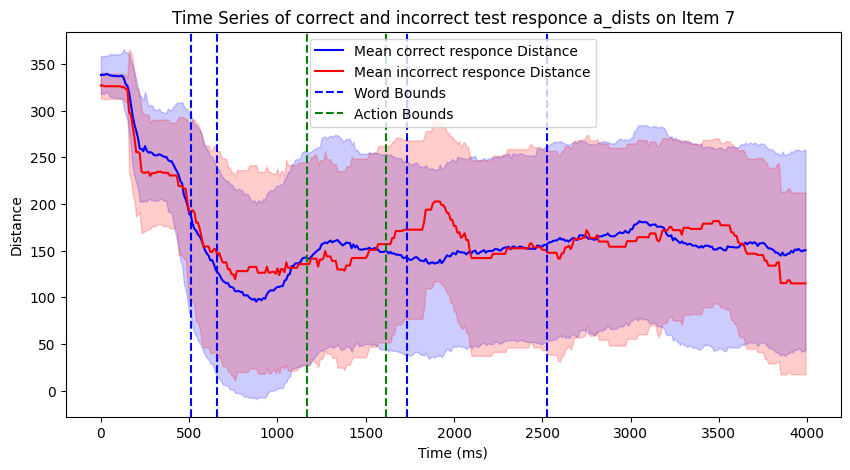

In [161]:
test_item = 7
dist_focus = 'a_dists'

# Filter DataFrame for the test item
edited_df = complete_df[complete_df['item'] == test_item]
edited_df_correct = edited_df[edited_df['test_accuracy'] == True]
edited_df_incorrect = edited_df[edited_df['test_accuracy'] == False]

# Extract mean onsets and offsets
the1_onset = results_df[results_df["item"] == test_item]["the1_onset"].mean()
agent_onset = results_df[results_df["item"] == test_item]["agent_onset"].mean()
agent_offset = results_df[results_df["item"] == test_item]["agent_offset"].mean()
the2_onset = results_df[results_df["item"] == test_item]["the2_onset"].mean()
patient_onset = results_df[results_df["item"] == test_item]["patient_onset"].mean()
patient_offset = results_df[results_df["item"] == test_item]["patient_offset"].mean()

correct_array = np.array(edited_df_correct[dist_focus].tolist(), dtype=np.float64)
incorrect_array = np.array(edited_df_incorrect[dist_focus].tolist(), dtype=np.float64)

# Compute mean and variance while ignoring NaNs
correct_mean = np.nanmean(correct_array, axis=0)
correct_var = np.nanvar(correct_array, axis=0)

incorrect_mean = np.nanmean(incorrect_array, axis=0)
incorrect_var = np.nanvar(incorrect_array, axis=0)

# Create time points (assuming 10ms intervals)
time_points = np.arange(0, len(correct_mean) * 10, 10)  # in milliseconds

# Plot
plt.figure(figsize=(10, 5))

line1, = plt.plot(time_points, correct_mean, label="Mean correct responce Distance", color='b')
plt.fill_between(time_points, 
                 correct_mean - np.sqrt(correct_var),  
                 correct_mean + np.sqrt(correct_var),  
                 color='b', alpha=0.2)

line2, = plt.plot(time_points, incorrect_mean, label="Mean incorrect responce Distance", color='r')
plt.fill_between(time_points, 
                 incorrect_mean - np.sqrt(incorrect_var),  
                 incorrect_mean + np.sqrt(incorrect_var),  
                 color='r', alpha=0.2)

# Add vertical lines for onsets and offsets
line4 = plt.axvline(x=the1_onset, color='b', linestyle='--', label="The1 Onset")
line5 = plt.axvline(x=agent_onset, color='b', linestyle='--', label="Agent Onset")
line6 = plt.axvline(x=agent_offset, color='g', linestyle='--', label="Agent Offset")
line7 = plt.axvline(x=the2_onset, color='g', linestyle='--', label="The2 Onset")
line8 = plt.axvline(x=patient_onset, color='b', linestyle='--', label="Patient Onset")
line9 = plt.axvline(x=patient_offset, color='b', linestyle='--', label="Patient Offset")

# Remove grid lines
plt.grid(False)

# Include only certain items
plt.legend([line1, line2, line5, line7], 
           ["Mean correct responce Distance", "Mean incorrect responce Distance", "Word Bounds", "Action Bounds"])

# Labels and Title
plt.xlabel("Time (ms)")
plt.ylabel("Distance")
plt.title(f"Time Series of correct and incorrect test responce {dist_focus} on Item {test_item}")

# Show the plot
plt.show()